In [ ]:
# 必要なライブラリをインポート
from datetime import datetime

import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 日本語フォント設定
# plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")
plt.style.use("default")

In [ ]:
# 日本語フォント設定
matplotlib.rc("font", family="IPAexGothic")

In [ ]:
# 学習済みモデルの読み込み
print("=== 学習済みモデル読み込み ===")
try:
    model = lgb.Booster(model_file="model/lgbm_model.txt")
    print("モデル読み込み成功!")
    print(f"特徴量数: {model.num_feature()}")
    print(f"学習ラウンド数: {model.num_trees()}")
except FileNotFoundError:
    print("エラー: model/lgbm_model.txt が見つかりません")
    print("先にtrain_lgbm.ipynbでモデルを学習してください")
    raise

=== 学習済みモデル読み込み ===
モデル読み込み成功!
特徴量数: 13
学習ラウンド数: 96


In [ ]:
# 予測用データの読み込み
print("=== 予測用データ読み込み ===")
try:
    pred_df = pd.read_csv("data/pred.csv")
    print(f"データ形状: {pred_df.shape}")
    print(f"カラム一覧: {pred_df.columns.tolist()}")

    # データの基本情報
    print(f"\n=== データ概要 ===")
    print(f"総レコード数: {len(pred_df)}")
    print(f"レース数: {len(pred_df) // 6} (想定)")
    print(f"欠損値: {pred_df.isnull().sum().sum()}")

    pred_df.head()
except FileNotFoundError:
    print("エラー: data/pred.csv が見つかりません")
    print("先にcreate_features.py pred [日付]で予測用データを作成してください")
    raise

=== 予測用データ読み込み ===
データ形状: (936, 13)
カラム一覧: ['枠番', '年齢', '体重', '級別', '全国勝率', '全国2連率', '当地勝率', '当地2連率', 'モーター2連率', 'ボート2連率', 'レース内全国勝率差', 'レース内全国2連率差', 'レース内モーター2連率差']

=== データ概要 ===
総レコード数: 936
レース数: 156 (想定)
欠損値: 0


=== 予測実行 ===
予測完了!
予測確率の統計:
最小値: 0.0008
最大値: 0.8137
平均値: 0.1634
標準偏差: 0.1915


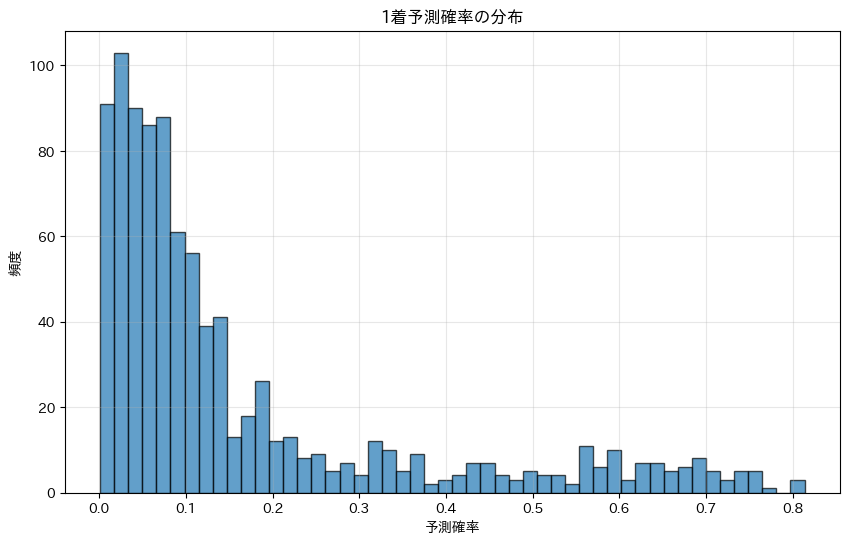

In [ ]:
# 予測実行
print("=== 予測実行 ===")
predictions = model.predict(pred_df, num_iteration=model.best_iteration)

# 予測結果をデータフレームに追加
pred_results = pred_df.copy()
pred_results["1着予測確率"] = predictions
pred_results["予測順位"] = 0  # 初期化

print(f"予測完了!")
print(f"予測確率の統計:")
print(f"最小値: {predictions.min():.4f}")
print(f"最大値: {predictions.max():.4f}")
print(f"平均値: {predictions.mean():.4f}")
print(f"標準偏差: {predictions.std():.4f}")

# 予測確率の分布を表示
plt.figure(figsize=(10, 6))
plt.hist(predictions, bins=50, alpha=0.7, edgecolor="black")
plt.title("1着予測確率の分布")
plt.xlabel("予測確率")
plt.ylabel("頻度")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# レース毎の予測順位を計算
print("=== レース毎予測順位計算 ===")

# 枠番をレースIDとして使用（簡易的にレースを識別）
# 実際のレースIDがない場合は、6艇ずつグループ化
race_groups = []
for i in range(0, len(pred_results), 6):
    race_group = pred_results.iloc[i : i + 6].copy()
    if len(race_group) == 6:  # 6艇揃っている場合のみ処理
        # 予測確率の降順で順位付け
        race_group = race_group.sort_values("1着予測確率", ascending=False)
        race_group["予測順位"] = range(1, 7)
        race_groups.append(race_group)

# 結果を統合
if race_groups:
    final_results = pd.concat(race_groups, ignore_index=True)

    print(f"処理レース数: {len(race_groups)}")
    print(f"総艇数: {len(final_results)}")

    # 枠番別の予測順位分布
    print(f"\n=== 枠番別予測順位分布 ===")
    rank_by_frame = (
        final_results.groupby("枠番")["予測順位"].value_counts().unstack(fill_value=0)
    )
    print(rank_by_frame)

    # 枠番別の平均予測確率
    print(f"\n=== 枠番別平均予測確率 ===")
    prob_by_frame = (
        final_results.groupby("枠番")["1着予測確率"].agg(["mean", "std"]).round(4)
    )
    print(prob_by_frame)
else:
    print("エラー: 6艇1組のレースデータが見つかりません")

=== レース毎予測順位計算 ===
処理レース数: 156
総艇数: 936

=== 枠番別予測順位分布 ===
予測順位    1   2   3   4   5    6
枠番                            
1     148   8   0   0   0    0
2       5  55  41  31  20    4
3       1  43  49  42  17    4
4       2  37  37  43  31    6
5       0   9  15  30  69   33
6       0   4  14  10  19  109

=== 枠番別平均予測確率 ===
      mean     std
枠番                
1   0.5361  0.1523
2   0.1258  0.0794
3   0.1237  0.0869
4   0.1069  0.0761
5   0.0562  0.0453
6   0.0317  0.0387


/tmp/ipykernel_12552/702978174.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(frame_data, labels=range(1, 7))


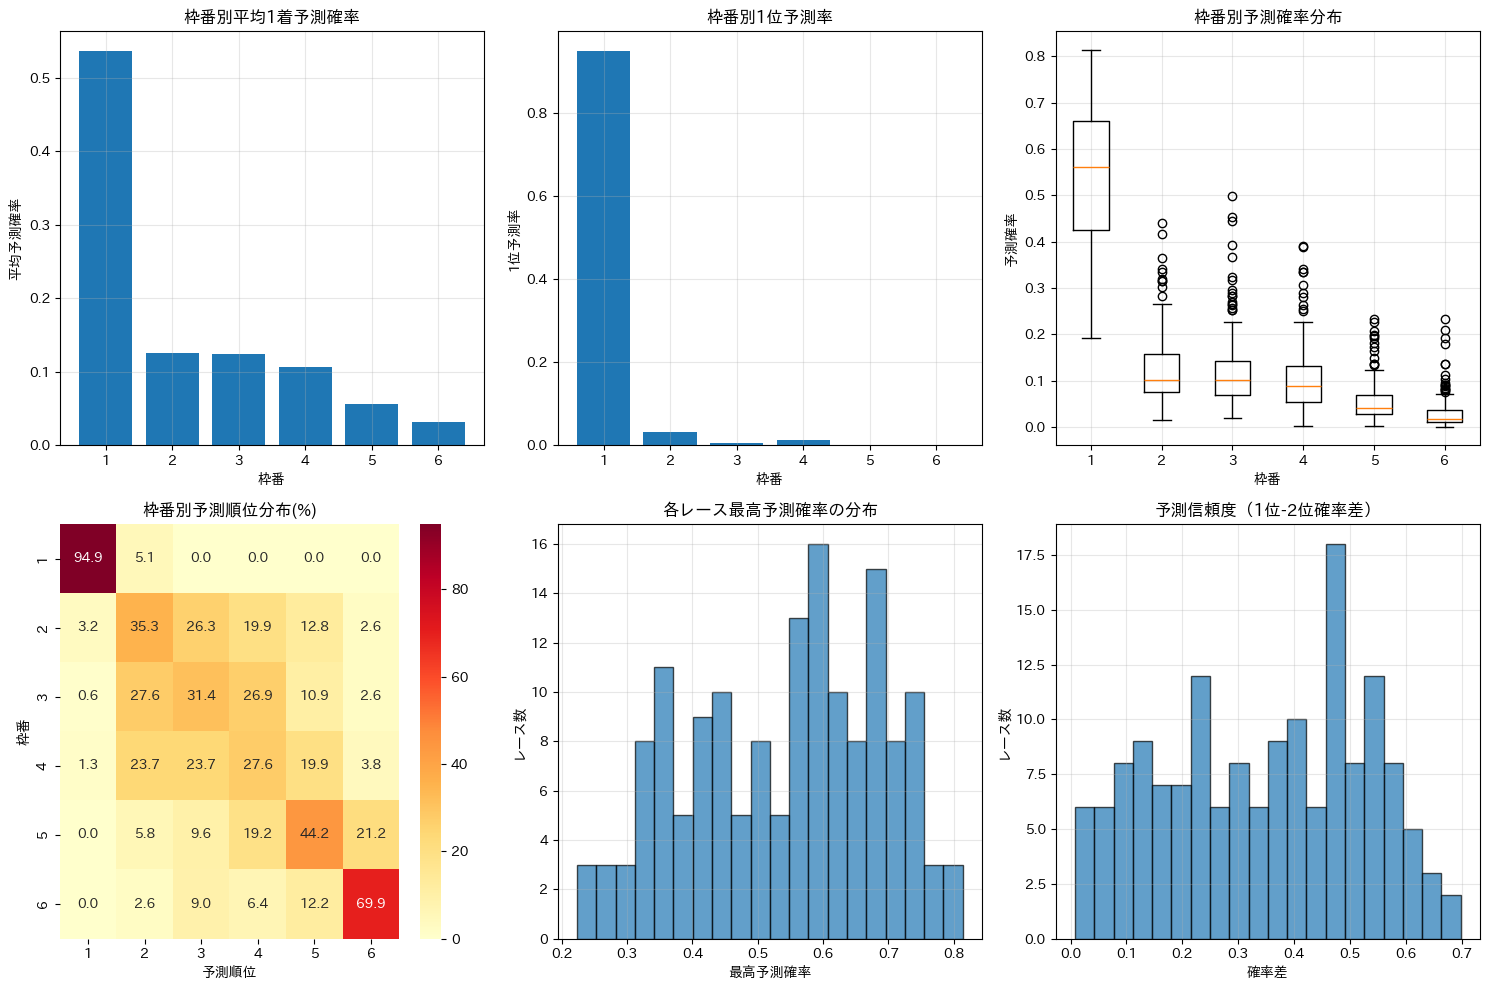


=== 予測信頼度統計 ===
平均信頼度: 0.3462
高信頼度レース数 (差>0.1): 138
低信頼度レース数 (差<0.05): 9


In [ ]:
# 枠番別予測分析の可視化
if race_groups:
    plt.figure(figsize=(15, 10))

    # 枠番別平均予測確率
    plt.subplot(2, 3, 1)
    frame_prob = final_results.groupby("枠番")["1着予測確率"].mean()
    plt.bar(frame_prob.index, frame_prob.values)
    plt.title("枠番別平均1着予測確率")
    plt.xlabel("枠番")
    plt.ylabel("平均予測確率")
    plt.grid(True, alpha=0.3)

    # 枠番別1位予測率
    plt.subplot(2, 3, 2)
    rank1_rate = final_results.groupby("枠番")["予測順位"].apply(
        lambda x: (x == 1).mean()
    )
    plt.bar(rank1_rate.index, rank1_rate.values)
    plt.title("枠番別1位予測率")
    plt.xlabel("枠番")
    plt.ylabel("1位予測率")
    plt.grid(True, alpha=0.3)

    # 予測確率のボックスプロット
    plt.subplot(2, 3, 3)
    frame_data = [
        final_results[final_results["枠番"] == i]["1着予測確率"].values
        for i in range(1, 7)
    ]
    plt.boxplot(frame_data, labels=range(1, 7))
    plt.title("枠番別予測確率分布")
    plt.xlabel("枠番")
    plt.ylabel("予測確率")
    plt.grid(True, alpha=0.3)

    # 予測順位分布（ヒートマップ）
    plt.subplot(2, 3, 4)
    rank_dist = (
        final_results.groupby("枠番")["予測順位"].value_counts().unstack(fill_value=0)
    )
    rank_dist_pct = rank_dist.div(rank_dist.sum(axis=1), axis=0) * 100
    sns.heatmap(rank_dist_pct, annot=True, fmt=".1f", cmap="YlOrRd")
    plt.title("枠番別予測順位分布(%)")
    plt.xlabel("予測順位")
    plt.ylabel("枠番")

    # 高予測確率レースの分析
    plt.subplot(2, 3, 5)
    high_prob_races = []
    for race_group in race_groups:
        max_prob = race_group["1着予測確率"].max()
        high_prob_races.append(max_prob)

    plt.hist(high_prob_races, bins=20, alpha=0.7, edgecolor="black")
    plt.title("各レース最高予測確率の分布")
    plt.xlabel("最高予測確率")
    plt.ylabel("レース数")
    plt.grid(True, alpha=0.3)

    # 予測の信頼度分析
    plt.subplot(2, 3, 6)
    confidence_scores = []
    for race_group in race_groups:
        sorted_probs = race_group["1着予測確率"].sort_values(ascending=False)
        if len(sorted_probs) >= 2:
            confidence = sorted_probs.iloc[0] - sorted_probs.iloc[1]
            confidence_scores.append(confidence)

    plt.hist(confidence_scores, bins=20, alpha=0.7, edgecolor="black")
    plt.title("予測信頼度（1位-2位確率差）")
    plt.xlabel("確率差")
    plt.ylabel("レース数")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n=== 予測信頼度統計 ===")
    print(f"平均信頼度: {np.mean(confidence_scores):.4f}")
    print(f"高信頼度レース数 (差>0.1): {sum(1 for c in confidence_scores if c > 0.1)}")
    print(
        f"低信頼度レース数 (差<0.05): {sum(1 for c in confidence_scores if c < 0.05)}"
    )

In [ ]:
# 予測結果のサンプル表示と保存
if race_groups:
    print("=== 予測結果サンプル（上位5レース） ===")

    # 各レースの最高予測確率でソート
    race_max_probs = []
    for i, race_group in enumerate(race_groups[:5]):  # 最初の5レースを表示
        max_prob = race_group["1着予測確率"].max()
        max_frame = race_group.loc[race_group["1着予測確率"].idxmax(), "枠番"]
        race_max_probs.append((i + 1, max_prob, max_frame, race_group))

    # 最高予測確率でソート
    race_max_probs.sort(key=lambda x: x[1], reverse=True)

    for race_num, max_prob, max_frame, race_group in race_max_probs:
        print(
            f"\n--- レース{race_num} (最高確率: {max_prob:.3f}, 予想1位: {max_frame}枠) ---"
        )
        display_cols = ["枠番", "年齢", "級別", "全国勝率", "1着予測確率", "予測順位"]
        race_display = race_group[display_cols].sort_values("予測順位")
        for _, row in race_display.iterrows():
            print(
                f"{row['枠番']}枠: 確率{row['1着予測確率']:.3f} (順位{row['予測順位']}) "
                f"年齢{row['年齢']} 級別{row['級別']} 勝率{row['全国勝率']}"
            )

    # 予測結果をCSVファイルに保存
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_file = f"data/predictions_{timestamp}.csv"
    final_results.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n=== 予測結果保存 ===")
    print(f"ファイル名: {output_file}")
    print(f"レコード数: {len(final_results)}")
    print(f"レース数: {len(race_groups)}")

    # 簡易的な買い目提案
    print(f"\n=== 買い目提案（参考） ===")
    high_confidence_races = [
        (i + 1, race_group)
        for i, race_group in enumerate(race_groups)
        if race_group["1着予測確率"].max() > 0.3  # 30%以上の確率
    ]

    if high_confidence_races:
        print(f"高信頼度レース数: {len(high_confidence_races)}")
        for race_num, race_group in high_confidence_races[:3]:  # 上位3レース
            top_frame = race_group.loc[race_group["1着予測確率"].idxmax(), "枠番"]
            top_prob = race_group["1着予測確率"].max()
            print(f"レース{race_num}: {top_frame}枠単勝 (確率{top_prob:.1%})")
    else:
        print("高信頼度レースはありません（最高確率<30%）")
else:
    print("予測結果がありません")

=== 予測結果サンプル（上位5レース） ===

--- レース1 (最高確率: 0.693, 予想1位: 1枠) ---
1.0枠: 確率0.693 (順位1.0) 年齢37.0 級別3.0 勝率6.36
2.0枠: 確率0.118 (順位2.0) 年齢27.0 級別1.0 勝率4.84
6.0枠: 確率0.071 (順位3.0) 年齢23.0 級別1.0 勝率6.02
3.0枠: 確率0.038 (順位4.0) 年齢59.0 級別1.0 勝率4.24
4.0枠: 確率0.029 (順位5.0) 年齢45.0 級別0.0 勝率3.85
5.0枠: 確率0.024 (順位6.0) 年齢27.0 級別1.0 勝率3.81

--- レース2 (最高確率: 0.617, 予想1位: 1枠) ---
1.0枠: 確率0.617 (順位1.0) 年齢32.0 級別1.0 勝率5.15
3.0枠: 確率0.154 (順位2.0) 年齢37.0 級別2.0 勝率5.61
2.0枠: 確率0.090 (順位3.0) 年齢24.0 級別1.0 勝率4.76
5.0枠: 確率0.082 (順位4.0) 年齢40.0 級別2.0 勝率5.4
4.0枠: 確率0.052 (順位5.0) 年齢54.0 級別1.0 勝率3.52
6.0枠: 確率0.018 (順位6.0) 年齢27.0 級別1.0 勝率4.37

--- レース3 (最高確率: 0.445, 予想1位: 3枠) ---
3.0枠: 確率0.445 (順位1.0) 年齢52.0 級別3.0 勝率6.82
1.0枠: 確率0.323 (順位2.0) 年齢34.0 級別1.0 勝率3.82
2.0枠: 確率0.184 (順位3.0) 年齢27.0 級別1.0 勝率4.83
5.0枠: 確率0.072 (順位4.0) 年齢46.0 級別1.0 勝率4.78
4.0枠: 確率0.056 (順位5.0) 年齢35.0 級別1.0 勝率4.5
6.0枠: 確率0.009 (順位6.0) 年齢23.0 級別0.0 勝率1.95

--- レース4 (最高確率: 0.443, 予想1位: 1枠) ---
1.0枠: 確率0.443 (順位1.0) 年齢52.0 級別1.0 勝率5.42
3.0枠: 確率0.100 (順位2.0) 年齢44.